In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import integrate
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import csv, json
from sklearn.metrics import root_mean_squared_error,mean_squared_error
import numpy as np

from statsmodels.stats.weightstats import ttost_ind
import statsmodels.formula.api as smf
import statsmodels.api as sm
# use the dedicated RMSE function (sklearn ≥1.4)
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error([1,2,3], [1.1,1.9,3.2])
print(rmse)
import statsmodels
print(statsmodels.__version__)


0.14142135623730964
0.14.2


In [2]:
# !pip install statsmodels

In [22]:
import sys, inspect, sklearn, sklearn.metrics as M
print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("Signature:", inspect.signature(M.mean_squared_error))
print("From module:", M.mean_squared_error.__module__)
print("Kernel executable:", sys.executable)

Python: 3.12.2 (v3.12.2:6abddd9f6a, Feb  6 2024, 17:02:06) [Clang 13.0.0 (clang-1300.0.29.30)]
scikit-learn: 1.7.2
Signature: (y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')
From module: sklearn.metrics._regression
Kernel executable: /Users/nilmaabbas/Documents/GitHub/Energy_logger_CPU/.venv/bin/python


# Read me

This script relies on the data being chunked by "DataChunking_sigmark_overheadtest.ipynb" and that we have obtained one csv file for each of the tests. If in doubt, check your "ChunkedData" folder.

The following imports the chunked data and provides us with two dataframes:
- dfs which holds the energy data for all the test
- df_powers holds all the power measurements for all the tests

After the import, the data is ready for your 

In [69]:
input_directory = '../ChunkedData'
output_directory = '../Results/'

In [71]:
# this part reads the chunked data files related to the 

In [79]:
# ls ../ChunkedData

In [81]:
# pd.read_csv('../ChunkedData_Stress/sigmark_0_siglent.1762858356709.CH1.csv',nrows=1,header=0)

# we want to  keep id2, exp_duration, count as  test, exp_duration, no_of_messages

In [83]:
#import all the CSV files

# (a) Read from row 3 and on into df and calculate energy consumption
# (b) Read the first two lines with meta data, add the calculated energy consumption and concat to the existing
ID = 0
list_of_metadataframes = []
list_of_dataframes = []
for input_file in os.listdir(input_directory):
    file_path = input_directory+'/'
    file_name = os.path.basename(input_file)
    if file_name.endswith('.csv'):
        print(input_file)
        df = pd.read_csv(file_path+file_name,skiprows=2, names=['timestamp','channel','action','payload'])
        # print(file_path+file_name,df['timestamp'].dtypes)
        df['time'] = (df['timestamp']-df['timestamp'].min()) / 1000
        df['ID'] = ID
        x = df['time']
        y = df['payload']
        y_int = integrate.cumulative_trapezoid(y, x, initial=0)
        #plt.plot(x, y_int)
        #plt.plot(x,y)
        #plt.savefig('')
        #plt.show()
        energy = y_int[-1]
        df_main = pd.read_csv(file_path+file_name,nrows=1,header=0,usecols = [1,4,5],names=['test','exp_duration','no_of_messages'])
        df_main['duration']=df['time'].max() # in seconds
        df_main['energy']=energy  # in joules
        df_main['power_avg']= energy/df_main['duration'] # in Watt
        df_main['ID'] = ID
        # print(df_main)
        df['test']=df_main['test'][0]
        df['no_of_messages']=df_main['no_of_messages'][0]
        df['ID'] = ID
        list_of_metadataframes.append(df_main)
        list_of_dataframes.append(df)
        ID = ID + 1

#dfs = pd.concat(list_of_metadataframes)
#df_power = pd.concat(list_of_dataframes)


sigmark_10_1764594415302_siglent.1764662359266.CH1_homemade_script.csv
sigmark_2_1764590716437_siglent.1764662359266.CH1_homemade_script.csv
sigmark_1_1764599881769_siglent.1764662359266.CH1_homemade_script.csv
sigmark_20_1764592646945_siglent.1764662359266.CH1_homemade_script.csv
sigmark_20_1764593772502_siglent.1764662359266.CH1_homemade_script.csv
sigmark_2_1764592404726_siglent.1764662359266.CH1_homemade_script.csv
sigmark_20_1764597149171_siglent.1764662359266.CH1_homemade_script.csv
sigmark_1_1764598193471_siglent.1764662359266.CH1_homemade_script.csv
sigmark_1_1764585249860_siglent.1764662359266.CH1_homemade_script.csv
sigmark_5_1764602936987_siglent.1764662359266.CH1_homemade_script.csv
sigmark_4_1764587822391_siglent.1764662359266.CH1_homemade_script.csv
sigmark_2_1764584526130_siglent.1764662359266.CH1_homemade_script.csv
sigmark_1_1764590796774_siglent.1764662359266.CH1_homemade_script.csv
sigmark_10_1764593852531_siglent.1764662359266.CH1_homemade_script.csv
sigmark_5_17645

In [86]:
dfs =pd.concat(list_of_metadataframes)

In [88]:
dfs = dfs.sort_values(by='test')
dfs = dfs.reset_index(drop=True)

In [90]:
dfs

,test,exp_duration,no_of_messages,duration,energy,power_avg,ID
0,1,81235,80,81.230,195.746275,2.409778,122
1,1,81226,80,81.209,196.174000,2.415668,140
2,1,80015,0,80.008,189.231600,2.365158,139
3,1,81239,80,81.222,195.708150,2.409546,138
4,1,81247,80,81.241,195.612600,2.407806,136
...,...,...,...,...,...,...,...
240,20,80075,4,80.069,189.330550,2.364592,128
241,20,80074,4,80.071,189.835700,2.370842,134
242,20,80076,4,80.056,189.180025,2.363096,173
243,20,80077,4,80.067,188.934225,2.359702,59


In [92]:
df_powers = pd.concat(list_of_dataframes)

In [94]:
df_powers = df_powers.reset_index(drop=True)

In [95]:
df_powers

,timestamp,channel,action,payload,time,ID,test,no_of_messages
0,1764594495393,CH1,POWER,2.35,0.000,0,10,8
1,1764594495397,CH1,POWER,2.35,0.004,0,10,8
2,1764594495403,CH1,POWER,2.35,0.010,0,10,8
3,1764594495407,CH1,POWER,2.35,0.014,0,10,8
4,1764594495415,CH1,POWER,2.35,0.022,0,10,8
...,...,...,...,...,...,...,...,...
3467291,1764589833087,CH1,POWER,2.35,81.202,244,1,80
3467292,1764589833095,CH1,POWER,2.35,81.210,244,1,80
3467293,1764589833101,CH1,POWER,2.35,81.216,244,1,80
3467294,1764589833106,CH1,POWER,2.35,81.221,244,1,80


# Nilma and Jespers Evaluation

The above imports the chunked data and provides us with two dataframes:
- dfs which holds the energy data for all the test
- df_powers holds all the power measurements for all the tests

1. Ultimately, we want to find out how much energy the raspberry pi is using per tick. 
2. We need to verify whether we can trust the data. 

<Axes: xlabel='no_of_messages', ylabel='energy'>

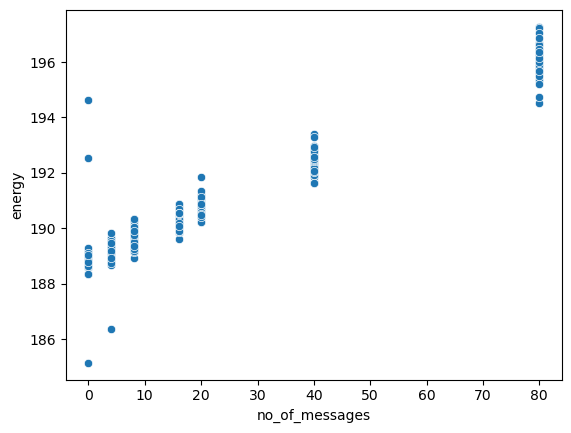

In [99]:
# first, we want to know how much energy is used for each number_of_messages

sns.scatterplot(data= dfs, x='no_of_messages',y='energy')

In [115]:


def remove_outliers_iqr(data, k=1.5, column="energy"):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    return data[(data[column] >= lower) & (data[column] <= upper)]

dfs_filtered = (
    dfs
    .groupby('no_of_messages', group_keys=False)
    .apply(remove_outliers_iqr)
)

/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_48377/1182068376.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers_iqr)


<Axes: xlabel='no_of_messages', ylabel='energy'>

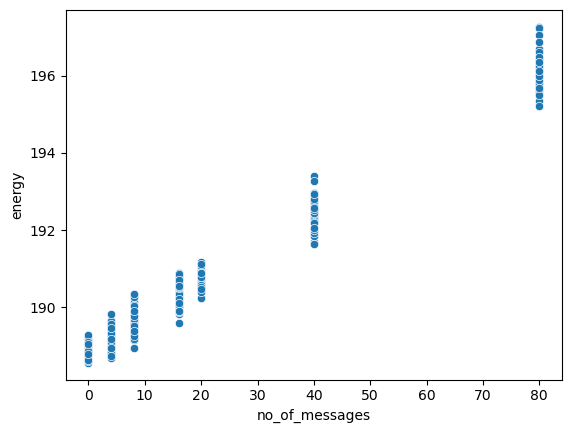

In [117]:
sns.scatterplot(data= dfs_filtered, x='no_of_messages',y='energy')


### The Best-fit Global Model

$\text{energy} = a \cdot \text{number of messages} + b$

- $a$: baseline slope (effect of sending a message).
- $b$: global intercept (baseline energy when number of messages = 0).

R-squared (R²) is defined as a number that tells you how well the independent variable(s) in a statistical model explains the variation in the dependent variable. It ranges from 0 to 1, where 1 indicates a perfect fit of the model to the data.

While R² is often between 0 and 1, it can be negative when the model performs worse than predicting the mean of the data.

                            OLS Regression Results                            
Dep. Variable:                 energy   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                 1.102e+04
Date:                Fri, 30 Jan 2026   Prob (F-statistic):          3.40e-198
Time:                        09:53:00   Log-Likelihood:                -80.676
No. Observations:                 235   AIC:                             165.4
Df Residuals:                     233   BIC:                             172.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        188.8422      0.031   6156.

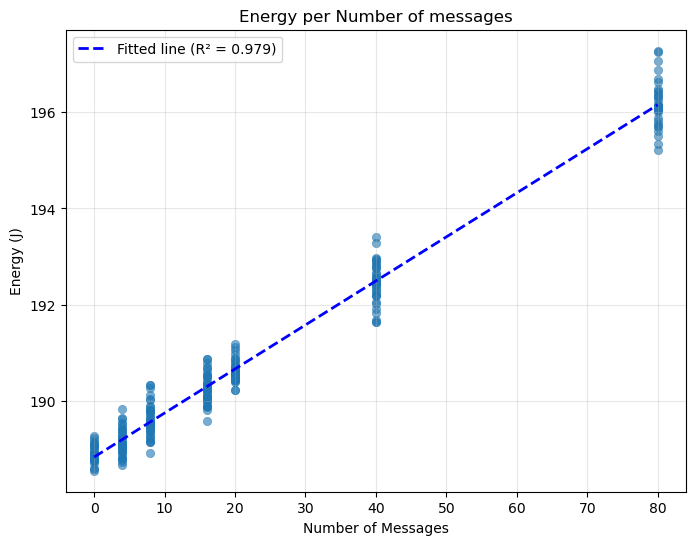

In [191]:
model = smf.ols("energy ~ no_of_messages", data=dfs_filtered).fit()
print(model.summary())

# Scatterplot of error vs duration
plt.figure(figsize=(8,6))
sns.scatterplot(x="no_of_messages", y="energy", data=dfs_filtered, alpha=0.6, edgecolor=None)

# Regression line (from statsmodels fit)
x_vals = np.linspace(dfs_filtered["no_of_messages"].min(), dfs_filtered["no_of_messages"].max(), 200)
y_vals = model.params['Intercept'] + model.params['no_of_messages']*x_vals  # from the regression model

r2_text = f"Fitted line (R² = {model.rsquared:.3f})"
plt.plot(x_vals, y_vals, color="blue", linewidth=2, linestyle='--',label=r2_text)

plt.title("Energy per Number of messages")
plt.ylabel('Energy (J)')
plt.xlabel('Number of Messages')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(output_directory+'energy_pr_no_of_message.png')
plt.show()

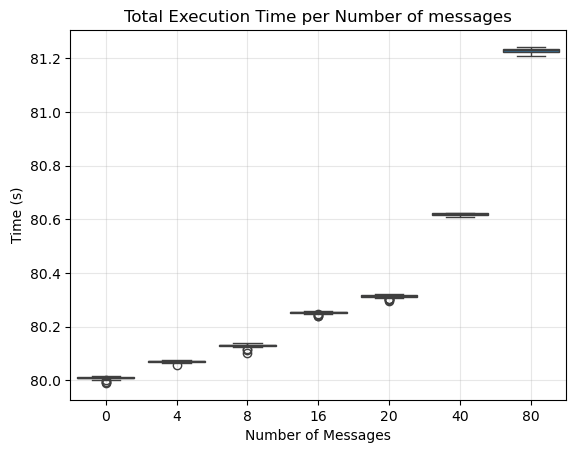

In [201]:
sns.boxplot(data= dfs, x='no_of_messages',y='duration')
plt.title("Total Execution Time per Number of messages")
plt.ylabel('Time (s)')
plt.xlabel('Number of Messages')
plt.grid(alpha=0.3)
plt.savefig(output_directory+'eduration_pr_no_of_message_boxplot.png')
plt.show()

                            OLS Regression Results                            
Dep. Variable:               duration   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.067e+06
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        10:56:47   Log-Likelihood:                 877.00
No. Observations:                 235   AIC:                            -1750.
Df Residuals:                     233   BIC:                            -1743.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         80.0078      0.001   1.54e

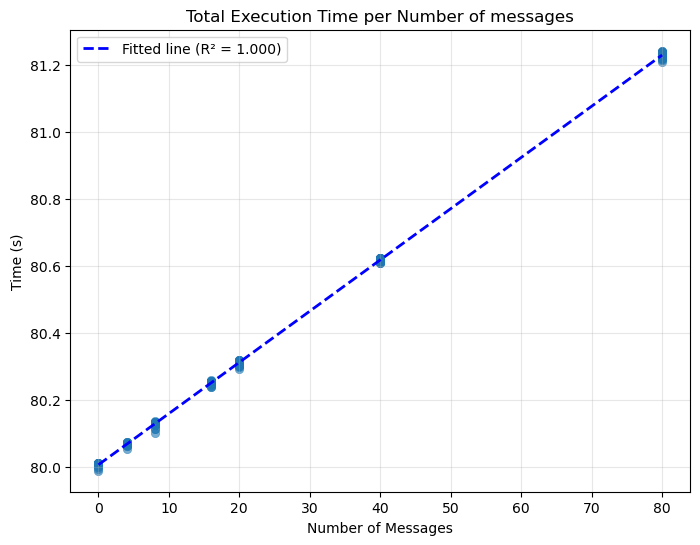

In [203]:
model = smf.ols("duration ~ no_of_messages", data=dfs_filtered).fit()
print(model.summary())

# Scatterplot of error vs duration
plt.figure(figsize=(8,6))
sns.scatterplot(x="no_of_messages", y="duration", data=dfs_filtered, alpha=0.6, edgecolor=None)

# Regression line (from statsmodels fit)
x_vals = np.linspace(dfs_filtered["no_of_messages"].min(), dfs_filtered["no_of_messages"].max(), 200)
y_vals = model.params['Intercept'] + model.params['no_of_messages']*x_vals  # from the regression model

r2_text = f"Fitted line (R² = {model.rsquared:.3f})"
plt.plot(x_vals, y_vals, color="blue", linewidth=2, linestyle='--',label=r2_text)

plt.title("Total Execution Time per Number of messages")
plt.ylabel('Time (s)')
plt.xlabel('Number of Messages')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(output_directory+'duration_pr_no_of_message.png')
plt.show()